# From global to local · NE-spectrum

A separate implementation for **Fashion-MNIST, MNIST, and 20 Newsgroups** using [NE-spectrum](https://github.com/sciai-lab/ne-spectrum) and its native `TSNESpectrum` backend. The DREAMS fits, layouts and environment remain separate.

The spectrum varies **attraction exaggeration ρ**, from 8 down to 1. Strong attraction emphasizes global neighbor structure; ρ=1 is ordinary t-SNE. The first layout is initialized from scaled PCA, but the global endpoint is an optimized neighbor embedding, **not an analytic PCA layout**. Later layouts continue from the previous raw optimized embedding and reuse its affinities. Labels only control sampling, colors and hover content.

Use the **ZoomMap NE-spectrum research** kernel. Installation and execution are documented in [README.rst](README.rst). This notebook shares the dataset loaders, font and coordinate interpolation helpers with the DREAMS example; optimizer caches and generated artifacts live under ne_spectrum/.

Both techniques show the [DREAMS paper's quality metrics](https://arxiv.org/html/2508.13747#S5.SS1) in their slider boxes, including intermediate zoom layouts. Text features use the same pinned, normalized MPNet embeddings as the DREAMS example.


In [1]:
import os
from pathlib import Path
import sys
import json
from concurrent.futures import ThreadPoolExecutor
from contextlib import chdir
from importlib.metadata import distribution

PROJECT = Path.cwd().resolve()
if PROJECT.name in {"notebooks", "ne_spectrum"}:
    PROJECT = PROJECT.parent
assert (PROJECT / "pyproject.toml").exists(), "Start from zoommap/ or zoommap/ne_spectrum/"
EXPERIMENT = PROJECT / "ne_spectrum"
DATA = EXPERIMENT / "data"
SOURCE_DATA = PROJECT / "data"  # shared downloads/MPNet vectors; never DREAMS optimizer caches
ARTIFACTS = EXPERIMENT / "artifacts"
DATA.mkdir(exist_ok=True)
ARTIFACTS.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(DATA / "matplotlib"))
os.environ.setdefault("NUMBA_CACHE_DIR", str(DATA / "numba"))
os.environ.setdefault("XDG_CACHE_HOME", str(DATA / "cache"))
os.environ.setdefault("KEOPS_CACHE_FOLDER", str(DATA / "keops"))
sys.path.insert(0, str(PROJECT / "notebooks"))
sys.path.insert(0, str(EXPERIMENT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
with chdir(distribution("opinionated").locate_file("opinionated")):
    import opinionated
from IPython.display import display, HTML
import datamapplot
from zoommap import ZoomPositions, ZoomKeyframe
from dataset_helpers import load_example_dataset
from experiment_helpers import align_for_display, use_bundled_jost
from quality_metrics import evaluate_zoom_quality, quality_javascript
from helpers import NE_SPECTRUM_COMMIT, fit_ne_spectrum, spectrum_plot_ui

print("DataMapPlot:", datamapplot.__file__)
print("NE-spectrum revision:", NE_SPECTRUM_COMMIT)


/Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/.venv/lib/python3.12/site-packages/opinionated/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DataMapPlot: /Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/.venv/lib/python3.12/site-packages/datamapplot/__init__.py
NE-spectrum revision: c980702a2594ee628fc86c36902f8c699c80b67e


## Shared settings

By default each dataset uses **5,000 training observations**: 500 per digit/clothing class or 250 per newsgroup topic. Set SAMPLE_SIZE to None for the full available training data; full datasets retain their original unequal class counts. Downloads and raw optimizer results are cached.

Perplexity is fixed at 150 throughout each sequence. ρ controls attraction exaggeration; its local endpoint is 1. Nonuniform zoom offsets allow denser keyframes where layouts change most. One zoom unit doubles camera magnification.

Two independent dataset sweeps may run concurrently; N_JOBS is the thread count per optimizer. Set PARALLEL_DATASETS to 1 to run them sequentially.

All Matplotlib plots use [Opinionated](https://github.com/MNoichl/opinionated) with the `opinionated_j` (Jost) preset. The interactive HTML maps use the same typeface for headings, legends, controls and hover content.

In [2]:
DATASETS = ["fashion_mnist", "mnist", "20_newsgroups"]
SAMPLE_SIZE = 5000
SEED = 42
N_ITER = 500
N_JOBS = 4
PARALLEL_DATASETS = 2
PERPLEXITY = 150
EXAGGERATIONS = [8.0, 6.0, 3.0, 2.0, 1.5, 1.0]
ZOOM_OFFSETS = [0.0, 0.7, 1.05, 1.25, 1.55, 2.5]

# Text-specific preprocessing. Images use PCA-50 on pixels divided by 255.
TEXT_MODEL = "sentence-transformers/all-mpnet-base-v2"
TEXT_MODEL_REVISION = "e8c3b32edf5434bc2275fc9bab85f82640a19130"
EMBEDDING_BATCH_SIZE = 32
EMBEDDING_DEVICE = None       # automatic accelerator selection; or "cpu", "mps", "cuda"
TEXT_MAX_SEQ_LENGTH = 384     # wordpieces, including special tokens

# Use Opinionated's Jost stylesheet for all Matplotlib plots.
PLOT_STYLE = "opinionated_j"
plt.style.use(PLOT_STYLE)
plt.rcParams["axes.titlesize"] = 11
PLOT_BACKGROUND = "#eff0eb"
plt.rcParams["figure.facecolor"] = PLOT_BACKGROUND
plt.rcParams["axes.facecolor"] = PLOT_BACKGROUND
plt.rcParams["savefig.facecolor"] = PLOT_BACKGROUND
PLOT_FONT = plt.rcParams["font.sans-serif"][0]
assert PLOT_FONT == "Jost"
print(f"Plot style: {PLOT_STYLE}; font: {PLOT_FONT}")

EQUALIZE_SCALE = True
INTERPOLATION = "linear"       # "linear" or "pchip"
EASING = "linear"              # "linear", "smoothstep", "smootherstep"
assert DATASETS and len(DATASETS) == len(set(DATASETS))
assert len(EXAGGERATIONS) == len(ZOOM_OFFSETS)
assert PARALLEL_DATASETS >= 1

QUALITY_GRID_SIZE = 101
QUALITY_SUBSET_SIZE = 1000

Plot style: opinionated_j; font: Jost


## Prepare image and text features

**Fashion-MNIST and MNIST:** use the original 28×28 grayscale training images, divide pixels by 255, then compute seeded PCA-50. The first two components supply the PCA initialization.

**20 Newsgroups:** load the training split with headers, footers, and quoted text removed. Exclude empty cleaned documents, then select a balanced sample. Encode the cleaned text with **sentence-transformers/all-mpnet-base-v2**, pinned to the model commit above, and L2-normalize the resulting **768-dimensional** vectors. A full PCA rotation centers these vectors and supplies the PCA initialization **without dropping dimensions or changing pairwise Euclidean distances**. NE-spectrum therefore uses the cosine geometry of the normalized MPNet embeddings.

MPNet uses at most **384 wordpieces per document**, including special tokens; longer documents are truncated. It embeds the document text, not the 1,200-character tooltip excerpt. Model weights and embeddings are cached locally; the vector cache includes text contents, row order, model revision, token settings and library versions. SentenceTransformers selects an available accelerator, falling back to CPU. Set EMBEDDING_DEVICE explicitly to override that choice.

The original training-row IDs stay attached to every observation. Preprocessing settings are exported separately for each dataset. Image tooltips show thumbnails; document tooltips show escaped excerpts from the cleaned text.

In [3]:
datasets = {}
for name in DATASETS:
    print(f"Preparing {name}…", flush=True)
    dataset = load_example_dataset(
        name, SOURCE_DATA, SAMPLE_SIZE, SEED,
        model_name=TEXT_MODEL,
        model_revision=TEXT_MODEL_REVISION, embedding_batch_size=EMBEDDING_BATCH_SIZE,
        embedding_device=EMBEDDING_DEVICE, max_seq_length=TEXT_MAX_SEQ_LENGTH,
    )
    datasets[name] = dataset
    settings = dict(dataset.preprocessing, requested_sample_size=SAMPLE_SIZE,
                    actual_sample_size=len(dataset.sample_ids))
    if "embedding_cache" in settings:
        settings["embedding_cache"] = str(Path(settings["embedding_cache"]).relative_to(PROJECT))
    (ARTIFACTS / f"{name}_preprocessing.json").write_text(json.dumps(settings, indent=2))
    print(f"{dataset.title}: {len(dataset.sample_ids):,} {dataset.noun}; "
          f"{dataset.features.shape[1]} feature dimensions", flush=True)
    display(pd.DataFrame({
        "class": dataset.class_names,
        "samples": np.bincount(dataset.labels, minlength=len(dataset.class_names)),
    }))
    display(pd.Series(settings, name="preprocessing"))

Preparing fashion_mnist…


Fashion-MNIST: 5,000 images; 50 feature dimensions


,class,samples
0,T-shirt/top,500
1,Trouser,500
2,Pullover,500
3,Dress,500
4,Coat,500
5,Sandal,500
6,Shirt,500
7,Sneaker,500
8,Bag,500
9,Ankle boot,500


subset                            train
pixel_scale               divide by 255
pca_components                       50
pca_explained_variance         0.864945
seed                                 42
requested_sample_size              5000
actual_sample_size                 5000
Name: preprocessing, dtype: object

Preparing mnist…


...

Preparing 20_newsgroups…


Sentence embeddings: reused embeddings-7d8e8a806322fa66.npz


20 Newsgroups · MPNet: 5,000 documents; 768 feature dimensions


,class,samples
0,alt.atheism,250
1,comp.graphics,250
2,comp.os.ms-windows.misc,250
3,comp.sys.ibm.pc.hardware,250
4,comp.sys.mac.hardware,250
5,comp.windows.x,250
6,misc.forsale,250
7,rec.autos,250
8,rec.motorcycles,250
9,rec.sport.baseball,250


source                                      scikit-learn fetch_20newsgroups
subset                                                                train
remove                                           [headers, footers, quotes]
original_documents                                                    11314
usable_documents                                                      11014
selected_documents                                                     5000
text_representation                                                   mpnet
document_filter                                       nonempty cleaned text
documents                                                              5000
embedding_dtype                                                     float32
long_document_policy      truncate each cleaned document to max_seq_leng...
max_seq_length                                                          384
model                               sentence-transformers/all-mpnet-base-v2
model_revisi

## Fit the native attraction spectrum

`TSNESpectrum.fit` computes all six slides using `use_previous_as_init=True`. The first fit uses tiny scaled PCA, with no separate early-exaggeration phase because the spectrum already begins at high attraction. Each following slide calls the preceding embedding's `optimize` method with the next ρ, preserving its affinities and coordinates.

We explicitly request **500 iterations at every slide**; otherwise the package defaults to only 50 continuation iterations. The ordered ρ values, processed features, observation IDs, seed, perplexity, initialization policy and dependency versions enter the cache identity. The entire native sequence is saved atomically. Timings refer to the whole sequence, not individual slides.

This sweep has no DREAMS regularizer or PCA penalty. Neither upstream NE-spectrum, upstream openTSNE nor DataMapPlot is patched. Warm starts improve continuity but remain dependent on sweep direction and intermediate attraction settings.


In [4]:
def fit_dataset(name):
    dataset = datasets[name]
    print(f"Starting {dataset.title}: perplexity={PERPLEXITY}, native warm starts", flush=True)
    fitted = fit_ne_spectrum(
        dataset.features, dataset.sample_ids, EXAGGERATIONS, DATA / "optimizer-cache" / name,
        seed=SEED, n_iter=N_ITER, n_jobs=N_JOBS, perplexity=PERPLEXITY,
    )
    print(f"Finished {dataset.title}: {fitted[2]}", flush=True)
    return fitted

results = {}
with ThreadPoolExecutor(max_workers=min(PARALLEL_DATASETS, len(DATASETS))) as pool:
    futures = {name: pool.submit(fit_dataset, name) for name in DATASETS}
    for name in DATASETS:
        raw_layouts, fit_report, cache_directory = futures[name].result()
        results[name] = {
            "raw_layouts": raw_layouts, "fit_report": fit_report,
            "cache_directory": cache_directory,
        }


Starting Fashion-MNIST: perplexity=150, native warm starts
Starting MNIST: perplexity=150, native warm starts


Slide 0 / 6 with Exaggeration: 8.0
Slide 0 / 6 with Exaggeration: 8.0


Slide 1 / 6 with Exaggeration: 6.0


Slide 1 / 6 with Exaggeration: 6.0


Slide 2 / 6 with Exaggeration: 3.0


...

Slide 2 / 6 with Exaggeration: 3.0


Slide 3 / 6 with Exaggeration: 2.0


Slide 4 / 6 with Exaggeration: 1.5


Slide 5 / 6 with Exaggeration: 1.0


Finished 20 Newsgroups · MPNet: /Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/data/optimizer-cache/20_newsgroups/7e629e91c5f65fce


## Align the display coordinates

Center each layout, equalize its RMS radius, and align its rotation to the first optimized global layout without reflections. Raw optimizer coordinates remain available in the archive. These similarities preserve neighbor recall and pairwise distance ranks.

The report records optimizer settings and RMS movement to the next keyframe. Paper-defined quality metrics are evaluated and added to this report once the actual zoom path is constructed below. All metrics compare against the original processed feature space; labels are unused.


In [5]:
reports = []
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    raw_layouts = result["raw_layouts"]
    layouts = align_for_display(raw_layouts, equalize_scale=EQUALIZE_SCALE)
    result["layouts"] = layouts
    report = result["fit_report"].copy()
    report.insert(0, "dataset", name)
    report["zoom_offset"] = ZOOM_OFFSETS
    report["rms_motion_to_next"] = [
        float(np.sqrt(np.mean(np.sum((b - a) ** 2, axis=1))))
        for a, b in zip(layouts[:-1], layouts[1:])
    ] + [np.nan]
    result["report"] = report
    reports.append(report)
    report.to_csv(ARTIFACTS / f"{name}_report.csv", index=False)
    np.savez_compressed(
        ARTIFACTS / f"{name}_layouts.npz",
        raw_positions=np.stack(raw_layouts), display_positions=np.stack(layouts),
        sample_ids=dataset.sample_ids, class_ids=dataset.labels,
        class_names=np.asarray(dataset.class_names),
        exaggerations=EXAGGERATIONS, zoom_offsets=ZOOM_OFFSETS,
        perplexity=PERPLEXITY, warm_start=True,
    )
    display(HTML(f"<h3>{dataset.title}</h3>"))
    display(report.round(3))
combined_report = pd.concat(reports, ignore_index=True)
combined_report.to_csv(ARTIFACTS / "general_example_report.csv", index=False)

,dataset,exaggeration,method,cached,n_iter,perplexity,initialization,sequence_compute_seconds,zoom_offset,rms_motion_to_next
0,fashion_mnist,8.0,NE-spectrum,False,500,150,scaled PCA,59.749,0.00,0.054
1,fashion_mnist,6.0,NE-spectrum,False,500,150,rho=8,59.749,0.70,0.121
2,fashion_mnist,3.0,NE-spectrum,False,500,150,rho=6,59.749,1.05,0.081
3,fashion_mnist,2.0,NE-spectrum,False,500,150,rho=3,59.749,1.25,0.049
4,fashion_mnist,1.5,NE-spectrum,False,500,150,rho=2,59.749,1.55,0.244
5,fashion_mnist,1.0,t-SNE endpoint,False,500,150,rho=1.5,59.749,2.50,NaN


,dataset,exaggeration,method,cached,n_iter,perplexity,initialization,sequence_compute_seconds,zoom_offset,rms_motion_to_next
0,mnist,8.0,NE-spectrum,False,500,150,scaled PCA,62.929,0.00,0.064
1,mnist,6.0,NE-spectrum,False,500,150,rho=8,62.929,0.70,0.104
2,mnist,3.0,NE-spectrum,False,500,150,rho=6,62.929,1.05,0.058
3,mnist,2.0,NE-spectrum,False,500,150,rho=3,62.929,1.25,0.023
4,mnist,1.5,NE-spectrum,False,500,150,rho=2,62.929,1.55,0.029
5,mnist,1.0,t-SNE endpoint,False,500,150,rho=1.5,62.929,2.50,NaN


,dataset,exaggeration,method,cached,n_iter,perplexity,initialization,sequence_compute_seconds,zoom_offset,rms_motion_to_next
0,20_newsgroups,8.0,NE-spectrum,False,500,150,scaled PCA,61.854,0.00,0.049
1,20_newsgroups,6.0,NE-spectrum,False,500,150,rho=8,61.854,0.70,0.107
2,20_newsgroups,3.0,NE-spectrum,False,500,150,rho=6,61.854,1.05,0.051
3,20_newsgroups,2.0,NE-spectrum,False,500,150,rho=3,61.854,1.25,0.035
4,20_newsgroups,1.5,NE-spectrum,False,500,150,rho=2,61.854,1.55,0.054
5,20_newsgroups,1.0,t-SNE endpoint,False,500,150,rho=1.5,61.854,2.50,NaN


## Compare the real keyframes

These panels show the actual computed layouts at a common display scale. Class/topic colors are fixed across the sequence.

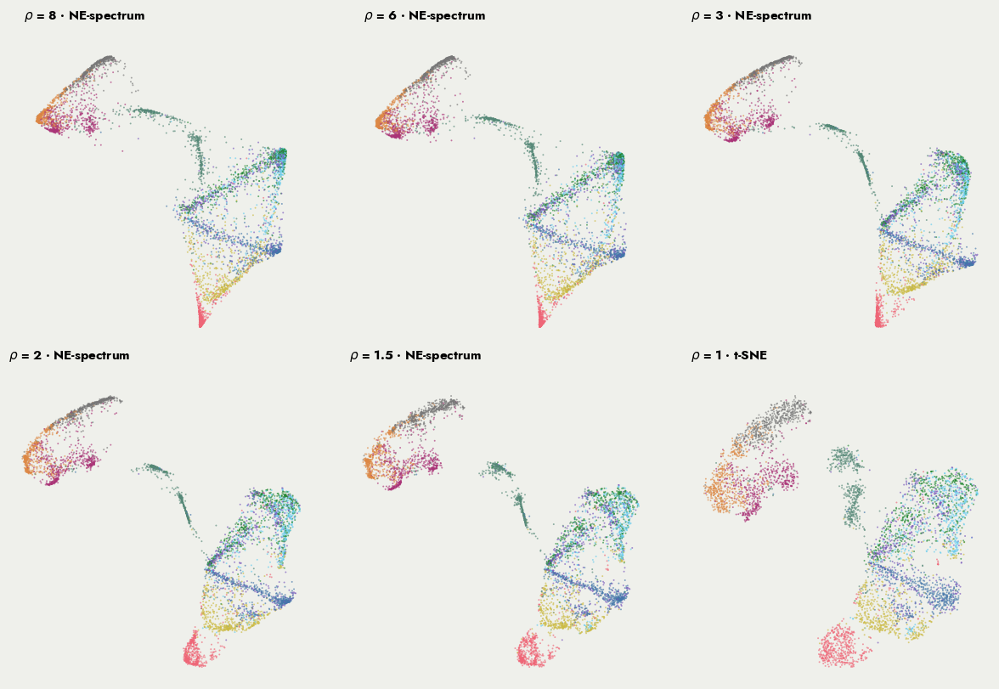

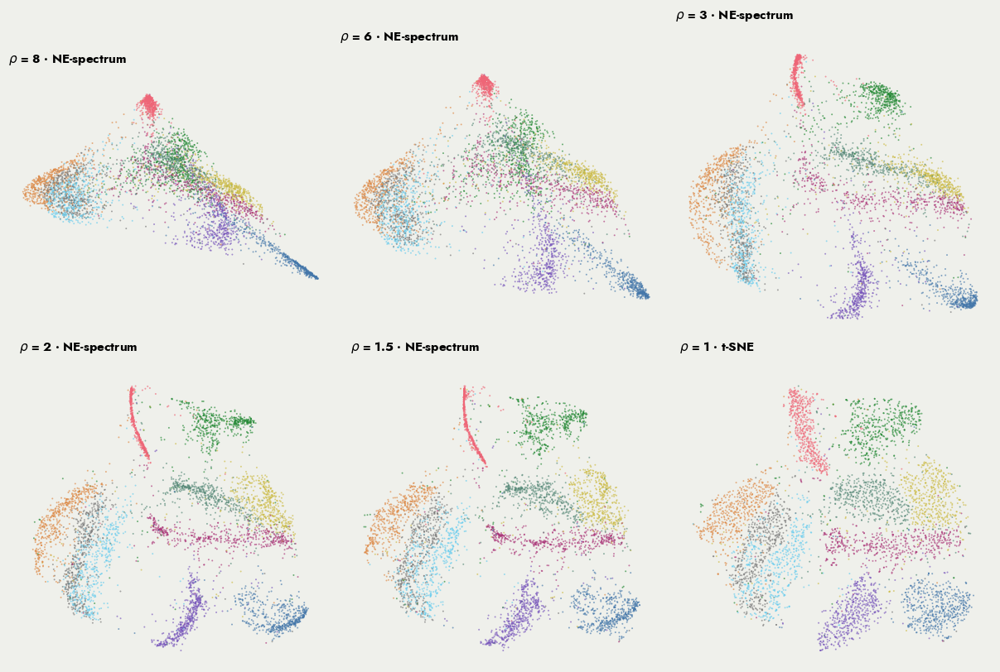

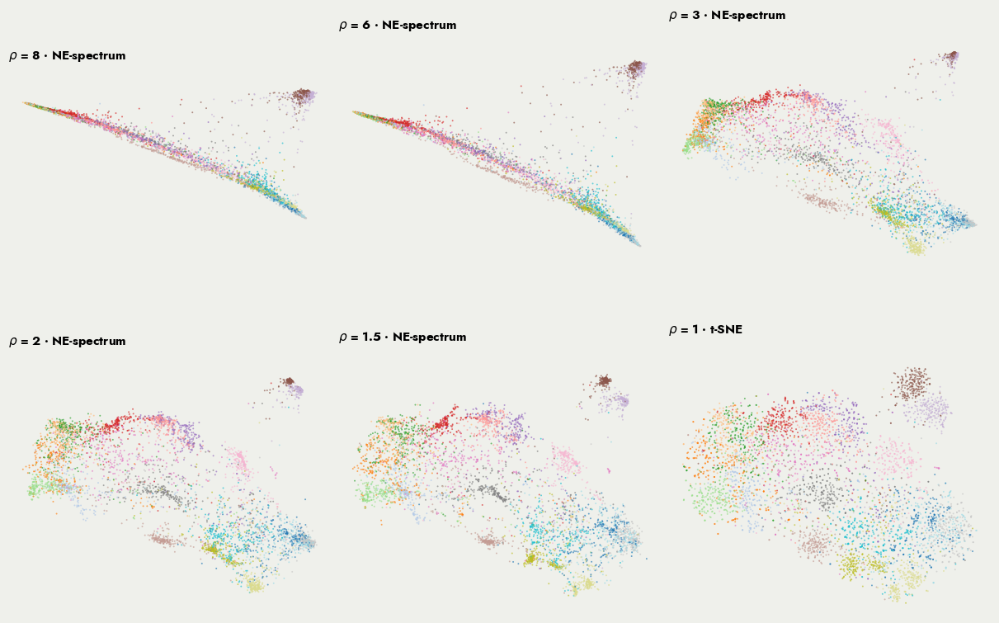

In [6]:
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    class_colors = np.asarray(dataset.colors)[dataset.labels]
    result["class_colors"] = class_colors
    fig, axes = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")
    for ax, positions, strength in zip(axes.flat, result["layouts"], EXAGGERATIONS):
        ax.scatter(positions[:, 0], positions[:, 1], c=class_colors, s=2, alpha=.65, linewidths=0)
        method = "t-SNE" if strength == 1 else "NE-spectrum"
        ax.set_title(f"$\\rho$ = {strength:g} · {method}")
        ax.set_aspect("equal")
        ax.set_axis_off()
    plt.show()

## Construct the ordered zoom keyframes

ZoomPositions accepts coordinates from any embedding method. Every frame must contain the same observations in the same row order. Zoom values can be unevenly spaced.

Linear interpolation takes straight segments. PCHIP uses a shape-preserving cubic on the actual zoom grid. Easing is independent: smoothstep or smootherstep stops movement at each knot. Per-interval options are also available through Transition objects.

In [7]:
for name in DATASETS:
    result = results[name]
    keyframes = [
        ZoomKeyframe(zoom, positions, f"ρ={strength:g}")
        for zoom, positions, strength in zip(ZOOM_OFFSETS, result["layouts"], EXAGGERATIONS)
    ]
    motion = ZoomPositions(keyframes, zoom_reference="initial",
                           interpolation=INTERPOLATION, easing=EASING)
    for frame in keyframes:
        np.testing.assert_allclose(motion.positions_at(frame.zoom), frame.positions, atol=1e-5)
    result.update(keyframes=keyframes, motion=motion)
    print(f"{datasets[name].title}: {len(keyframes)} keyframes, "
          f"{len(datasets[name].sample_ids):,} persistent point IDs")
    result["quality"] = evaluate_zoom_quality(
        datasets[name].features, datasets[name].sample_ids, motion,
        DATA / "quality-metrics" / name, seed=SEED,
        grid_size=QUALITY_GRID_SIZE, subset_size=QUALITY_SUBSET_SIZE,
    )
    quality_output = ARTIFACTS / "quality_metrics"
    quality_output.mkdir(exist_ok=True)
    (quality_output / f"{name}.json").write_text(json.dumps(result["quality"], indent=2))
    pd.DataFrame(result["quality"]["samples"]).to_csv(quality_output / f"{name}.csv", index=False)

    endpoints = pd.DataFrame(result["quality"]["samples"]).set_index("zoom").loc[ZOOM_OFFSETS]
    result["report"]["nn_recall"] = endpoints["nn_recall"].to_numpy()
    result["report"]["global_distance_spearman"] = endpoints["global_distance_spearman"].to_numpy()
    result["report"].to_csv(ARTIFACTS / f"{name}_report.csv", index=False)
combined_report = pd.concat([results[name]["report"] for name in DATASETS], ignore_index=True)
combined_report.to_csv(ARTIFACTS / "general_example_report.csv", index=False)
display(combined_report.round(3))


Fashion-MNIST: 6 keyframes, 5,000 persistent point IDs
Quality metrics: evaluated 1/101 zoom samples


/Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:134: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 264, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 420, in _count_physical_cores_darwin
    return int(cpu_info)
           ^^^^^^^^^^^^^


Quality metrics: evaluated 26/101 zoom samples


Quality metrics: evaluated 51/101 zoom samples


Quality metrics: evaluated 76/101 zoom samples


...

Quality metrics: evaluated 26/101 zoom samples


Quality metrics: evaluated 51/101 zoom samples


Quality metrics: evaluated 76/101 zoom samples


Quality metrics: evaluated 101/101 zoom samples


,dataset,exaggeration,method,cached,n_iter,perplexity,initialization,sequence_compute_seconds,zoom_offset,rms_motion_to_next,nn_recall,global_distance_spearman
0,fashion_mnist,8.0,NE-spectrum,False,500,150,scaled PCA,59.749,0.00,0.054,0.200,0.685
1,fashion_mnist,6.0,NE-spectrum,False,500,150,rho=8,59.749,0.70,0.121,0.204,0.681
2,fashion_mnist,3.0,NE-spectrum,False,500,150,rho=6,59.749,1.05,0.081,0.227,0.667
3,fashion_mnist,2.0,NE-spectrum,False,500,150,rho=3,59.749,1.25,0.049,0.262,0.661
4,fashion_mnist,1.5,NE-spectrum,False,500,150,rho=2,59.749,1.55,0.244,0.306,0.657
5,fashion_mnist,1.0,t-SNE endpoint,False,500,150,rho=1.5,59.749,2.50,NaN,0.423,0.683
6,mnist,8.0,NE-spectrum,False,500,150,scaled PCA,62.929,0.00,0.064,0.098,0.461
7,mnist,6.0,NE-spectrum,False,500,150,rho=8,62.929,0.70,0.104,0.109,0.472
8,mnist,3.0,NE-spectrum,False,500,150,rho=6,62.929,1.05,0.058,0.160,0.465
9,mnist,2.0,NE-spectrum,False,500,150,rho=3,62.929,1.25,0.023,0.213,0.434


## Export and display the interactive maps

This is the unchanged DataMapPlot function. ZoomPositions is passed through its existing custom_js parameter, alongside the optional example controls. Colors and image/document metadata are supplied once and remain attached to point IDs. Automatic point sizing lets dots grow naturally as you zoom in.

Each exported HTML file embeds its coordinates, hover metadata and Opinionated’s bundled Jost font. The optional font helper removes duplicate Google Fonts declarations from the generated HTML before saving and displaying it. It runs without Python, but uses the normal DataMapPlot CDN dependencies.

The slider box displays the [DREAMS paper's section 5.1 metrics](https://arxiv.org/html/2508.13747#S5.SS1): **10-neighbor recall over every observation**, and **Spearman correlation of pairwise distances among 1,000 fixed randomly sampled observations**. Labels are unused. We evaluate the actual interpolated coordinates at a dense zoom grid and every fitted keyframe. The browser linearly looks up these quality samples; values between samples are approximate, marked ≈. Camera magnification and viewport cropping do not change these whole-layout scores. The endpoint report uses the same 1,000-observation reference and 10-neighbor definition as the slider display.


Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/artifacts/fashion_mnist_zoom.html (3.91 MB)


<InteractiveFigure width=100% height=800>
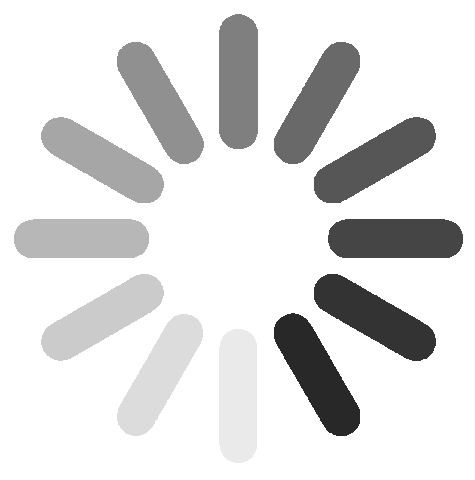

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/artifacts/mnist_zoom.html (2.32 MB)


<InteractiveFigure width=100% height=800>
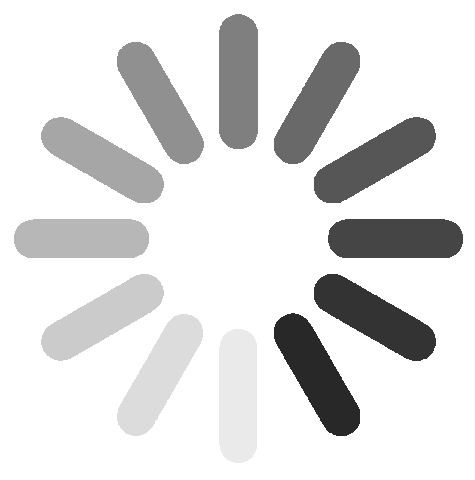

Saved /Users/Noich001/Desktop/moving_data_mapplot/zoommap/ne_spectrum/artifacts/20_newsgroups_zoom.html (2.67 MB)


<InteractiveFigure width=100% height=800>
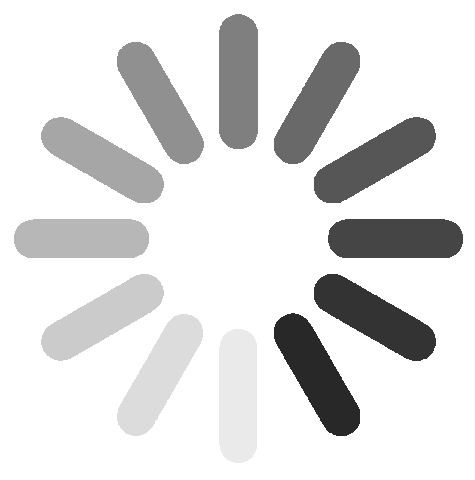

In [8]:
controls_js = (PROJECT / "notebooks" / "controls.js").read_text()
figures = {}
for name in DATASETS:
    dataset, result = datasets[name], results[name]
    custom_html, custom_css = spectrum_plot_ui(
        dataset.title, len(dataset.sample_ids), dataset.noun,
        dataset.class_names, dataset.colors, PERPLEXITY, global_exaggeration=EXAGGERATIONS[0],
    )
    figure = datamapplot.create_interactive_plot(
        result["layouts"][0], title=f"From global to local · {dataset.title}",
        marker_color_array=result["class_colors"],
        hover_text=[f"{dataset.class_names[int(label)]} · sample {index}"
                    for label, index in zip(dataset.labels, dataset.sample_ids)],
        extra_point_data=dataset.extra_data,
        hover_text_html_template=dataset.tooltip,
        point_radius_min_pixels=2.5, point_radius_max_pixels=10,
        point_size_scale=None, point_line_width=0,
        font_family=PLOT_FONT, tooltip_font_family=PLOT_FONT,
        background_color=PLOT_BACKGROUND, widgets=[], height=800,
        custom_html=custom_html, custom_css=custom_css,
        custom_js=result["motion"].to_javascript() + "\n" + controls_js + "\n" + quality_javascript(result["quality"]),
    )
    figure = use_bundled_jost(figure)
    output = ARTIFACTS / f"{name}_zoom.html"
    figure.save(str(output))
    figures[name] = figure
    print(f"Saved {output} ({output.stat().st_size / 1e6:.2f} MB)")
    display(HTML(f"<h3>{dataset.title}</h3>"))
    display(figure)

## Compare interpolation without recomputing embeddings

The following paths follow one original observation from each dataset. Both interpolation methods respect the same endpoints and uneven zoom grid. Edit the settings above and rerun the plotting cells to export another option; the expensive fits stay cached.

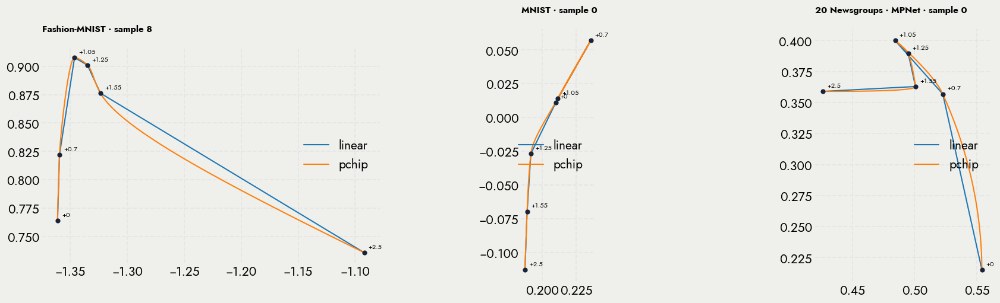

In [9]:
z = np.linspace(ZOOM_OFFSETS[0], ZOOM_OFFSETS[-1], 160)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6 * len(DATASETS), 5), squeeze=False, layout="constrained")
for ax, name in zip(axes.flat, DATASETS):
    dataset, result = datasets[name], results[name]
    probe = 0
    for method in ["linear", "pchip"]:
        path = ZoomPositions(result["keyframes"], interpolation=method)
        trajectory = np.asarray([path.positions_at(zoom)[probe] for zoom in z])
        ax.plot(trajectory[:, 0], trajectory[:, 1], label=method, linewidth=1.5)
    anchors = np.asarray([frame.positions[probe] for frame in result["keyframes"]])
    ax.scatter(anchors[:, 0], anchors[:, 1], color="#182238", s=24, zorder=3)
    for xy, zoom in zip(anchors, ZOOM_OFFSETS):
        ax.annotate(f"+{zoom:g}", xy, xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set_title(f"{dataset.title} · sample {dataset.sample_ids[probe]}")
    ax.set_aspect("equal")
    ax.legend()
plt.show()

The extension updates scatter positions and retains colors, filter attributes, point indices, and hover metadata. Labels, hulls, density tiles, minimaps, annotations, and lasso spatial indices require their own position updates and are absent here.

Zoom changes magnification and layout; pan keeps the current layout. Points can move away from the location under the cursor. Interpolated layouts are visual approximations between the real optimizer outputs.

Exports live in artifacts/: one interactive HTML map, coordinate archive, preprocessing description, quality report per dataset, plus a combined quality table. Root data/ holds the shared downloads, sentence embeddings and model weights. NE-spectrum optimizer caches and runtime files live in ne_spectrum/data/.

Everything specific to this experiment lives under ne_spectrum/. The original DREAMS coordinate archives, optimizer caches, environment and GIFs are retained.